# **Maestría en Inteligencia Artificial Aplicada**

## **Curso: Inteligencia Artificial y Aprendizaje Automático**

**Tecnológico de Monterrey**

Prof Luis Eduardo Falcón Morales

Actividad de Semana 3 - Septiembre 2024

**Rotación de Personal - IBM**

#### **Nombre y matrícula:**
Carlos Fernando Del Castillo Rey
A01796595

#### **La siguiente actividad se basa en los datos del archivo "WA_Fn-UseC_-HR-Employee-Attrition.csv" que se encuentra en la siguiente liga de Kaggle, llamada "IBM HR Analytics Employee Attrition & Performance":**

https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset


In [35]:
# Incluye aquí todas las librerías que consideres necesarias:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression  
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score 
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score



# **Ejercicio 1:**

#### **Incluye una breve introducción sobre lo que se entiende por el problema de rotación de personal en las organizaciones (employee attrition problem).**

++++++++ Inicia la sección de agregar texto: ++++++++++++

La rotación de personal es el fenómeno en el que los empleados de una organización deciden, voluntaria o involuntariamente, dejar sus puestos de trabajo.Es una problematia muy reelevante ya que afecta no solo la estabilidad de la empresa, sino también el rendimiento operativo,  y costos.


++++++++ Termina la sección de agregar texto. +++++++++++

# **Ejercicio 2:**

#### **Carga los datos del archivo de la página de Kaggle indicada como un DataFrame de Pandas, llamado "df" y utilicemos el método “describe” con el argumento include= “all”, para obtener una primera descripción general de cada variable.**

In [36]:
# ++++++++++++++ Inicia sección de agregar código ++++++++++++++++++++

# Cargar el conjunto de datos almacenado en equipo personal
df = pd.read_csv("C:\\Users\\52614\\.cache\\kagglehub\\datasets\\pavansubhasht\\ibm-hr-analytics-attrition-dataset\\versions\\1\\WA_Fn-UseC_-HR-Employee-Attrition.csv")

# Generar estadísticas descriptivas incluyendo todas las columnas y transponer el resultado
descripcion = df.describe(include='all').transpose()


# +++++++++++++ Termina sección de agregar código +++++++++++++++++++++


print("Tamaño del DataFrame:", df.shape)
df.describe(include = 'all').T


Tamaño del DataFrame: (1470, 35)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
Attrition,1470,2,No,1233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BusinessTravel,1470,3,Travel_Rarely,1043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DailyRate,1470.0,NaN,NaN,NaN,802.485714,403.5091,102.0,465.0,802.0,1157.0,1499.0
Department,1470,3,Research & Development,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1470.0,NaN,NaN,NaN,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,NaN,NaN,NaN,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
EducationField,1470,6,Life Sciences,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeCount,1470.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
EmployeeNumber,1470.0,NaN,NaN,NaN,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0


# **Ejercicio 3:**

#### **Indica cuál es la diferencia entre utilizar o no el argumento include=”all” del método "describe" en el ejercicio anterior.**

++++++++ Inicia la sección de agregar texto: ++++++++++++

Sin usar el "all" las columnas solo muestra el resumen estadisco en base a las variables numericas y con el all se muestran todos los tipos de variables

++++++++ Termina la sección de agregar texto. +++++++++++

# **Ejercicio 4:**

#### **Con base a la información desplegada por la instrucción anterior, hemos decidido cancelar los siguientes factores de nuestro problema: Over18, EmployeeCount, StandardHours, EmployeeNumber. Explica cuál es la justificación que nos permite cancelar cada uno de estos factores:**

++++++++ Inicia la sección de agregar texto: ++++++++++++

a) Over18:

Este factor no aporta variabilidad al análisis, ya que todos los empleados tienen el mismo valor. Es una columna que no aporta diferenciación entre empleados que permanecen en la empresa o dejan su puesto.

b) EmployeeCount:

Esta columna tiene un valor constante para todos los empleados. Dado que no tiene variabilidad, no puede ser utilizada para predecir o explicar el fenómeno de la rotación de personal.

c) StandardHours:

Esta variable tiene el mismo valor (80 horas) para todos los empleados. Esto indica que es un valor estándar establecido por la empresa y, por lo tanto, no es útil para identificar patrones en la atrición.

d) EmployeeNumber:

Este factor es simplemente un identificador único para cada empleado. No tiene significado estadístico o predictivo en el contexto del problema, ya que no contribuye a explicar la rotación. Además, podría introducir ruido si se utiliza como variable en los modelos.

++++++++ Termina la sección de agregar texto. +++++++++++




In [37]:
# Eliminamos los factores indicados:

df = df.drop(['Over18','EmployeeCount','StandardHours','EmployeeNumber'],axis=1)

print("Tamaño del nuevo DataFrame:", df.shape)

Tamaño del nuevo DataFrame: (1470, 31)


# **Ejercicio 5:**

#### **Realiza una partición de los datos en Entrenamiento, Validación y Prueba, del 70%, 15% y 15%, respectivamente. Llama a dichos conjuntos Xtrain, Xval, Xtest, ytrain, yval, ytest, para los datos de entrada y de salida, respectivamente. Asegúrate que dicha partición conserve la estratificación de las clases de la variable “Attrition”. Despliega además la dimensión obtenida de los tres conjuntos: Entrenamiento, Validación y Prueba.**

#### **NOTA: Utiliza semillas en cada función de partición, para permitir la repetibilidad de tu modelo y poder evaluarlo de mejor majera.**

In [38]:
# ++++++++++++++ Inicia sección de agregar código +++++++++++++++++++++


X = df.drop(columns=["Attrition"])
y = df["Attrition"]

# Semilla para reproducibilidad
SEED = 42

# Paso 1: Dividir los datos en conjunto de entrenamiento (70%) y restante (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)

# Paso 2: Dividir el conjunto restante en validación (15%) y prueba (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)

# Mostrar las dimensiones de cada conjunto
print("Dimensiones de los conjuntos:")
print(f"Entrenamiento: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Validación: X_val={X_val.shape}, y_val={y_val.shape}")
print(f"Prueba: X_test={X_test.shape}, y_test={y_test.shape}")

# ++++++++++++++ Termina sección de agregar código +++++++++++++++++++++

Dimensiones de los conjuntos:
Entrenamiento: X_train=(1029, 30), y_train=(1029,)
Validación: X_val=(220, 30), y_val=(220,)
Prueba: X_test=(221, 30), y_test=(221,)


# **Ejercicio 6:**


#### **Aplica la transformación LabelEncoder() de sklearn a la variable de salida “Attrition”. Las nuevas variables deberán llamarse ahora: ytrainT, yvalT, ytestT. Encuentra la proporción de datos en cada nivel de esta variable y con base a dicha información indica si podemos considerar que tenemos un problema de datos desbalanceados.**

#### NOTA: Aplica esta transformación evitando el filtrado de información (data leakage).

In [39]:
# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++


# Crear una instancia de LabelEncoder
label_encoder = LabelEncoder()

# Transformar las etiquetas de las variables de salida para Entrenamiento, Validación y Prueba
ytrainT = label_encoder.fit_transform(y_train)
yvalT = label_encoder.transform(y_val)
ytestT = label_encoder.transform(y_test)

# Convertir ytrainT en un DataFrame para compatibilidad con la línea final
ytrainT = pd.DataFrame(ytrainT, columns=["Porcentaje de datos en cada clase de entrenamiento - Attrition:"])

def calcular_proporciones(y, dataset_name):
    unique, counts = np.unique(y, return_counts=True)
    proportions = counts / len(y)
    print(f"Proporciones en {dataset_name}:")
    for value, proportion in zip(unique, proportions):
        print(f"Clase {value}: {proportion:.2%}")
    return proportions

# Proporciones en cada conjunto
proporcion_train = calcular_proporciones(ytrainT["Porcentaje de datos en cada clase de entrenamiento - Attrition:"], "Entrenamiento")
proporcion_val = calcular_proporciones(yvalT, "Validación")
proporcion_test = calcular_proporciones(ytestT, "Prueba")

# Determinar si el problema está desbalanceado
print("\nAnálisis del balance de clases:")
if any(proporcion < 0.2 for proporcion in [*proporcion_train, *proporcion_val, *proporcion_test]):
    print("El problema es de datos desbalanceados (clases con baja representación).\n")
else:
    print("Las clases están razonablemente balanceadas.\n")


# +++++++++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++

print(ytrainT['Porcentaje de datos en cada clase de entrenamiento - Attrition:'].value_counts() / ytrainT.shape[0])

Proporciones en Entrenamiento:
Clase 0: 83.87%
Clase 1: 16.13%
Proporciones en Validación:
Clase 0: 84.09%
Clase 1: 15.91%
Proporciones en Prueba:
Clase 0: 83.71%
Clase 1: 16.29%

Análisis del balance de clases:
El problema es de datos desbalanceados (clases con baja representación).

Porcentaje de datos en cada clase de entrenamiento - Attrition:
0    0.838678
1    0.161322
Name: count, dtype: float64


# **Ejercicio 7:**


#### **Incluye a continuación el análisis gáfico y describtivo que consideres adecuado. Con base a estos gráficos ¿qué tipo de transformaciones sugieres llevar a cabo en dichas variables?**

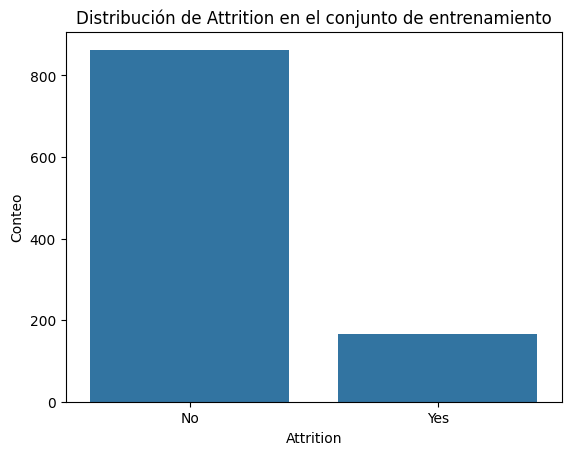

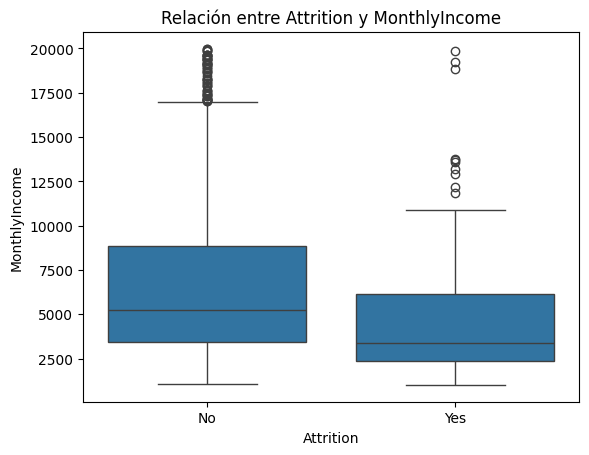

Resumen estadístico de MonthlyIncome según Attrition:
           count         mean          std     min      25%     50%     75%  \
Attrition                                                                     
No         863.0  6875.366165  4702.370370  1051.0  3419.50  5238.0  8859.0   
Yes        166.0  4847.765060  3674.519049  1009.0  2353.75  3373.5  6147.5   

               max  
Attrition           
No         19973.0  
Yes        19859.0  


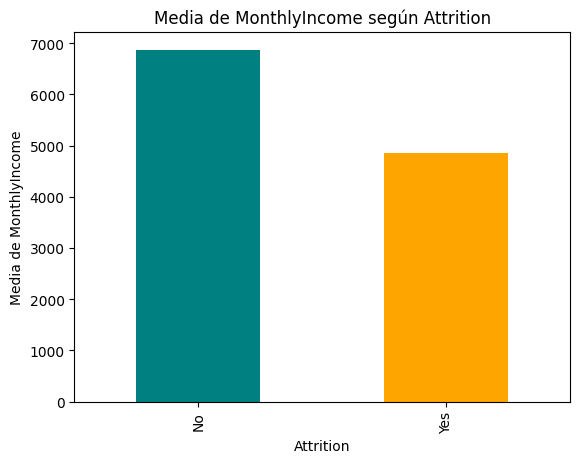

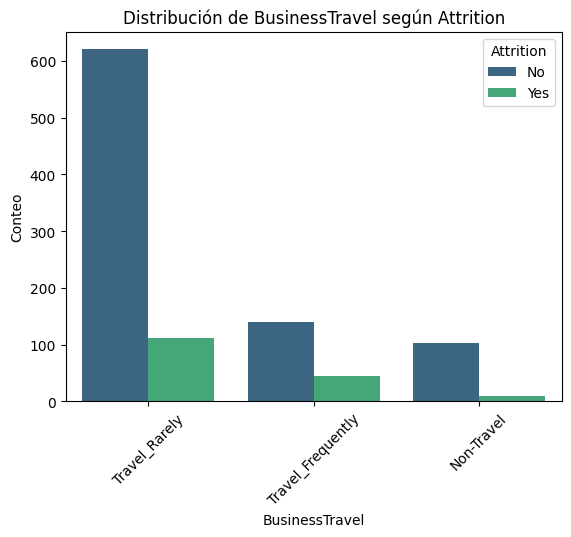

Tabla de contingencia entre BusinessTravel y Attrition:
Attrition           No  Yes
BusinessTravel             
Non-Travel         103    9
Travel_Frequently  140   45
Travel_Rarely      620  112


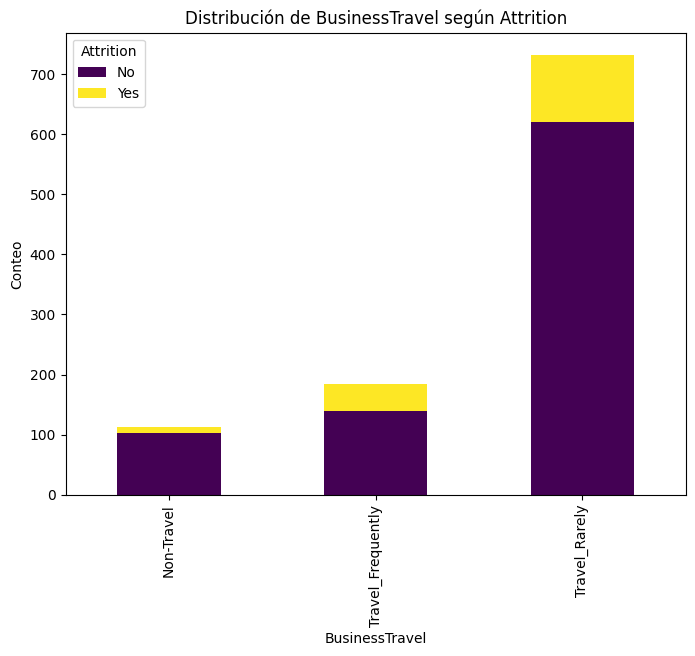

In [40]:


# ++++++++++++++ Análisis descriptivo de Attrition ++++++++++++++

# 1. Distribución de Attrition
sns.countplot(x=y_train)
plt.title("Distribución de Attrition en el conjunto de entrenamiento")
plt.xlabel("Attrition")
plt.ylabel("Conteo")
plt.show()

# 2. Boxplot entre Attrition y una variable numérica (MonthlyIncome)
sns.boxplot(x=y_train, y=X_train["MonthlyIncome"])
plt.title("Relación entre Attrition y MonthlyIncome")
plt.xlabel("Attrition")
plt.ylabel("MonthlyIncome")
plt.show()

# 3. Resumen estadístico de MonthlyIncome según Attrition
income_by_attrition = X_train.groupby(y_train)["MonthlyIncome"].describe()
print("Resumen estadístico de MonthlyIncome según Attrition:")
print(income_by_attrition)

#4 Visualización de las medias de MonthlyIncome según Attrition
income_means = X_train.groupby(y_train)["MonthlyIncome"].mean()
income_means.plot(kind="bar", color=["teal", "orange"])
plt.title("Media de MonthlyIncome según Attrition")
plt.xlabel("Attrition")
plt.ylabel("Media de MonthlyIncome")
plt.show()

# 5. Distribución de una variable categórica según Attrition (BusinessTravel)
sns.countplot(x=X_train["BusinessTravel"], hue=y_train, palette="viridis")
plt.title("Distribución de BusinessTravel según Attrition")
plt.xlabel("BusinessTravel")
plt.ylabel("Conteo")
plt.legend(title="Attrition")
plt.xticks(rotation=45)
plt.show()

# 6. Tabla de contingencia entre BusinessTravel y Attrition
contingency_table = pd.crosstab(X_train["BusinessTravel"], y_train)
print("Tabla de contingencia entre BusinessTravel y Attrition:")
print(contingency_table)

# Visualización de la tabla de contingencia
contingency_table.plot(kind="bar", stacked=True, colormap="viridis", figsize=(8, 6))
plt.title("Distribución de BusinessTravel según Attrition")
plt.xlabel("BusinessTravel")
plt.ylabel("Conteo")
plt.show()

# **Ejercicio 8:**

#### **Utiliza las clases Pipeline y ColumnTransformer de Sklearn para definir las transformaciones que deberán aplicarse a cada variable de acuerdo a su tipo.**



In [41]:
# +++++ Clasificación de columnas actualizada +++++
# Variables ordinales específicas, esto porque se decide usar un codifiacdor diferente ya que el campo de estudio si tiene orden
catOrd_pipeline_nombres = ["EducationField"]

categories_ordinal = [
    ["Life Sciences", "Medical", "Marketing", "Technical Degree", "Human Resources", "Other"]
]

# Pipeline para variables ordinales específicas
catOrd_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal_encoder", OrdinalEncoder(categories=categories_ordinal))
])

# Pipeline para variables numéricas
numericas_pipeline_nombres = [
    "Age", "DailyRate", "DistanceFromHome", "HourlyRate", "JobInvolvement", 
    "JobLevel", "MonthlyIncome", "MonthlyRate", "NumCompaniesWorked", 
    "PercentSalaryHike", "PerformanceRating", "RelationshipSatisfaction", 
    "StockOptionLevel", "TotalWorkingYears", "TrainingTimesLastYear", 
    "YearsAtCompany", "YearsInCurrentRole", "YearsSinceLastPromotion", 
    "YearsWithCurrManager", "Education", "EnvironmentSatisfaction", 
    "JobSatisfaction", "WorkLifeBalance"
]

# Variables binarias
catBin_pipeline_nombres = ["OverTime", "Gender"]

# Variables nominales (excluye EducationField)
catNom_pipeline_nombres = [
    "BusinessTravel", "Department", "JobRole", "MaritalStatus"
]



# Pipeline para variables numéricas
numericas_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

# Pipeline para variables binarias
catBin_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first"))
])

# Pipeline para variables nominales
catNom_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first"))
])

# +++++ Combinar los pipelines con ColumnTransformer +++++
columnasTransformer = ColumnTransformer(transformers=[
    ("numericas", numericas_pipeline, numericas_pipeline_nombres),
    ("binarias", catBin_pipeline, catBin_pipeline_nombres),
    ("nominales", catNom_pipeline, catNom_pipeline_nombres),
    ("ordinales", catOrd_pipeline, catOrd_pipeline_nombres)
])

# +++++ Aplicar las transformaciones +++++
# Transformar el conjunto de entrenamiento
X_train_transformed = columnasTransformer.fit_transform(X_train)

# Mostrar la forma del conjunto transformado
print("Shape de X_train transformado:", X_train_transformed.shape)



Shape de X_train transformado: (1029, 40)


# **Ejercicio 9:**

#### **Reagrupa los conjuntos de entrenamiento y validación en un solo DataFrame.**

#### **A estos nuevos DataFrame llamarlos Xtv y ytv.**

In [42]:
# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++


# Combinar los conjuntos de entrenamiento y validación para las características (X)
Xtv = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)

# Combinar los conjuntos de entrenamiento y validación para la variable objetivo (y)
ytv = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++

print(Xtv.shape)
print(ytv.shape)

(1249, 30)
(1249,)


# **Ejercicio 10:**

#### **Busca los mejores hiperparámetros.**

>> LR 0.872 (0.018)
>> LASSO 0.878 (0.016)
>> RIDGE 0.878 (0.014)
>> EN 0.877 (0.015)
>> kNN 0.837 (0.010)


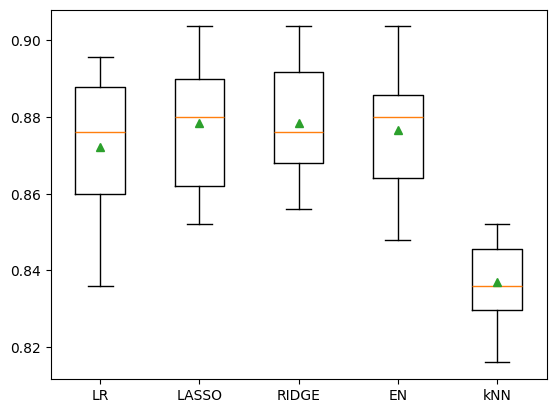

In [43]:
# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++


def mis_modelos():
  modelos, nombres = list(), list()

  # LR - Regresión Logística sin regularización:
  modelos.append(LogisticRegression(penalty=None,  # Este valor de "penalty" no se debe de cambiar, ya que define el modelo sin regularización.
                                     solver='lbfgs',          # Algoritmo de optimización
                                     max_iter=500,            # Número máximo de iteraciones
                                    fit_intercept=True,      # Ajustar intercepto,     
                                    random_state=1))
  nombres.append('LR')


  # Lasso - Regresión Logística con regularización L1:
  modelos.append(LogisticRegression(penalty='l1',
                                    solver='saga',
                                    C=1.0,                   # Intensidad de la regularización
                                    max_iter=500,
                                    random_state=1))
  nombres.append('LASSO')


  # Ridge - Regresión Logística con regularización L2:
  modelos.append(LogisticRegression(penalty='l2',
                                    solver='lbfgs',
                                    C=0.5,                   # Menor valor implica mayor regularización
                                    max_iter=500,     # Incluye aquí todos los hiperparámetros y valores que consideres adecuados.
                                    random_state=1))
  nombres.append('RIDGE')


  # Elastic_Net - - Regresión Logística con regularización L1 y L2:
  modelos.append(LogisticRegression(penalty='elasticnet',
                                    solver='saga',
                                    l1_ratio=0.5,            # 50% L1, 50% L2
                                    C=1.0,
                                    max_iter=500,
                                    random_state=1))
  nombres.append('EN')



  # kNN - k-Vecinos más cercanos:
  modelos.append(KNeighborsClassifier(
    n_neighbors=5,         # Número de vecinos
    metric='minkowski',    # Métrica de distancia
    p=2                    # Parámetro de la distancia (Euclidiana)
  )) 
  nombres.append('kNN')

  return modelos, nombres

# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++



# Entrenamos los modelos:

modelos, nombres = mis_modelos()  # accesando los modelos.
resultados = list()    # para guardar los resultados en esta lista.

# Iterando y entrenando sobre cada modelo:
for i in range(len(modelos)):

  pipeline = Pipeline(steps=[('ct',columnasTransformer),('m',modelos[i])])   # Transformaciones y modelo en un Pipeline.

  cv1 = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=7)     # Aplicando una de las variantes de Validación Cruzada.

  scores = cross_val_score(pipeline, Xtv, np.ravel(ytv), scoring='accuracy', cv=cv1)   # entrenando y generando los resultados.

  resultados.append(scores)    # guardando los resultados en la lista.
  print('>> %s %.3f (%.3f)' % (nombres[i], np.nanmean(scores), np.nanstd(scores)))  # desplegando los promedios de cada modelo.


plt.boxplot(resultados, tick_labels=nombres, showmeans=True)   # gráficos de caja para una comparación visual de los resultados.
plt.show()

# **Ejercicio 11:**

#### **Utilizando el mejor modelo y los datos Xtv, ytv, realiza una búsqueda de malla para encontrar los mejores hiperparámetros. Verifica que el modelo no esté subentrenado o sobreentrenado.**



In [44]:
# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++


# Configurar el pipeline
pipeline = Pipeline(steps=[('ct', columnasTransformer), 
                           ('model', LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000, random_state=1))])

# Definir el espacio de hiperparámetros para la búsqueda de malla
param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],   # Intensidad de la regularización
    'model__fit_intercept': [True, False]  # Ajustar o no el intercepto
}

# Configurar validación cruzada
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=7)

# Configurar GridSearchCV
grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=cv, scoring='accuracy', n_jobs=-1, verbose=1, return_train_score=True)

# Ajustar el modelo a los datos
grid_result = grid_search.fit(Xtv, np.ravel(ytv))

# Obtener el mejor modelo
mejor_modelo = grid_result.best_estimator_


# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++



print("Mejor modelo: %f usando %s" % (grid_result.best_score_, grid_result.best_params_))
print('Promedios Train mean(std): %.4f(%.4f)' % (np.nanmean(grid_result.cv_results_['mean_train_score']),
                                                 np.nanmean(grid_result.cv_results_['std_train_score'])))
print('Promedios Val mean(std): %.4f(%.4f)' % (grid_result.cv_results_['mean_test_score'].mean(),
                                               grid_result.cv_results_['std_test_score'].mean()))


Fitting 15 folds for each of 10 candidates, totalling 150 fits
Mejor modelo: 0.879383 usando {'model__C': 0.1, 'model__fit_intercept': True}
Promedios Train mean(std): 0.8806(0.0048)
Promedios Val mean(std): 0.8692(0.0141)


# **Ejercicio 12:**

#### **Con los mejores valores de hiperparámetros del mejor modelo encontrado, obtener:**

*   #### **a) Matriz de Confusión.**
*   #### **b) Análisis de Imprtancia de Factores.**
*   #### **c) Reporte de métricas.**

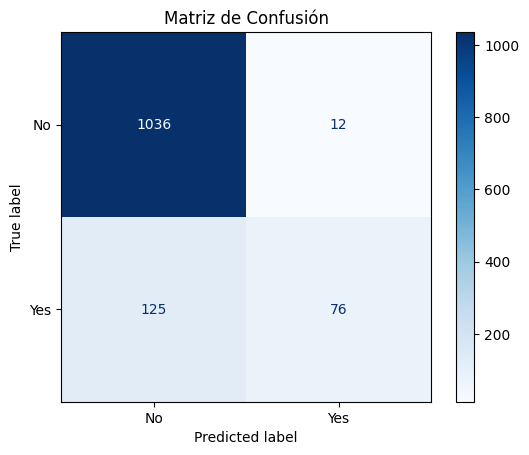


Análisis de Importancia de Factores:
                                          Factor  Importancia
23                        binarias__OverTime_Yes     1.290488
25   nominales__BusinessTravel_Travel_Frequently     0.666097
38               nominales__MaritalStatus_Single     0.490794
30      nominales__JobRole_Laboratory Technician     0.456705
17            numericas__YearsSinceLastPromotion     0.415202
20            numericas__EnvironmentSatisfaction    -0.402685
36       nominales__JobRole_Sales Representative     0.374152
8                  numericas__NumCompaniesWorked     0.368627
21                    numericas__JobSatisfaction    -0.363335
16                 numericas__YearsInCurrentRole    -0.328814
27  nominales__Department_Research & Development    -0.328669
12                   numericas__StockOptionLevel    -0.300932
0                                 numericas__Age    -0.288898
4                      numericas__JobInvolvement    -0.281430
13                  numericas__T

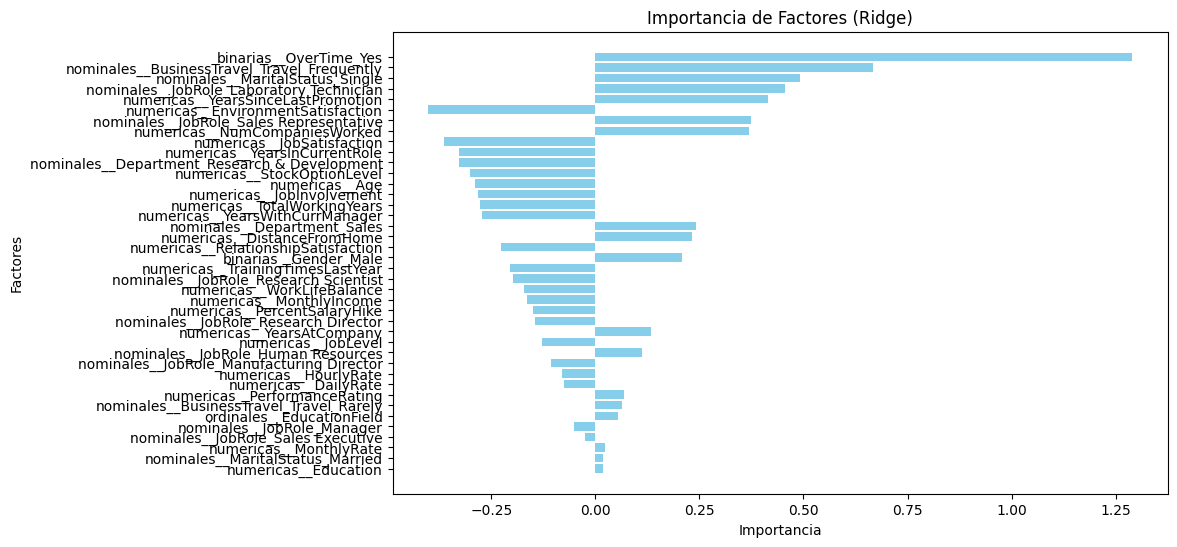


Reporte de Métricas:
              precision    recall  f1-score   support

          No       0.89      0.99      0.94      1048
         Yes       0.86      0.38      0.53       201

    accuracy                           0.89      1249
   macro avg       0.88      0.68      0.73      1249
weighted avg       0.89      0.89      0.87      1249



In [45]:
# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++
# Incluye todas las celdas que consideres adecuado para responder
# estos tres incisos del ejercicio.


# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++

# Predicciones en el conjunto Xtv con el mejor modelo
ytv_pred = mejor_modelo.predict(Xtv)

# Generar la matriz de confusión
cm = confusion_matrix(ytv, ytv_pred)

# Visualizar la matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=mejor_modelo.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión")
plt.show()

# +++++++++ b) Análisis de Importancia de Factores +++++++++

# Coeficientes del modelo (importancia de los factores)
coeficientes = mejor_modelo.named_steps['model'].coef_[0]  # Coeficientes del modelo (Logistic Regression)
factores = columnasTransformer.get_feature_names_out()     # Nombres de las variables
importancia = pd.DataFrame({'Factor': factores, 'Importancia': coeficientes})

# Ordenar los factores por importancia absoluta
importancia['Importancia Absoluta'] = np.abs(importancia['Importancia'])
importancia = importancia.sort_values(by='Importancia Absoluta', ascending=False)

print("\nAnálisis de Importancia de Factores:")
print(importancia[['Factor', 'Importancia']])

# Visualización de la importancia de factores
plt.figure(figsize=(10, 6))
plt.barh(importancia['Factor'], importancia['Importancia'], color='skyblue')
plt.xlabel('Importancia')
plt.ylabel('Factores')
plt.title('Importancia de Factores (Ridge)')
plt.gca().invert_yaxis()  # Invertir el eje para mostrar los factores más importantes en la parte superior
plt.show()

# +++++++++ c) Reporte de Métricas +++++++++

print("\nReporte de Métricas:")
print(classification_report(ytv, ytv_pred))
# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++

# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++

# **Ejercicio 13**

#### **Obtener el desempeño final del modelo (accuracy) con el conjunto de prueba (test).**

Accuracy en el conjunto de prueba: 0.8688


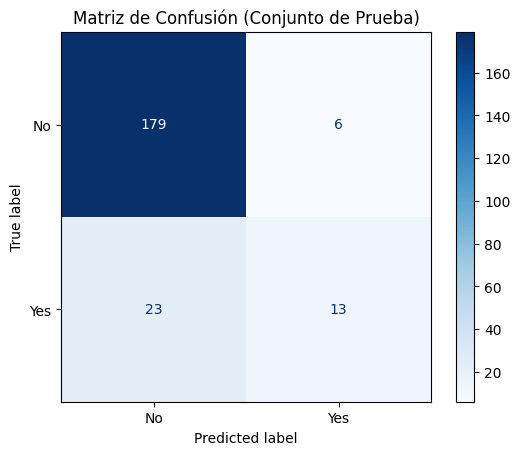


Reporte de Clasificación (Conjunto de Prueba):
              precision    recall  f1-score   support

          No       0.89      0.97      0.93       185
         Yes       0.68      0.36      0.47        36

    accuracy                           0.87       221
   macro avg       0.79      0.66      0.70       221
weighted avg       0.85      0.87      0.85       221



In [46]:


# Predecir con el conjunto de prueba (test)
y_test_pred = mejor_modelo.predict(X_test)

# Calcular el accuracy en el conjunto de prueba
accuracy_test = accuracy_score(y_test, y_test_pred)
print(f"Accuracy en el conjunto de prueba: {accuracy_test:.4f}")

# Matriz de confusión en el conjunto de prueba
cm_test = confusion_matrix(y_test, y_test_pred)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=mejor_modelo.classes_)
disp_test.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión (Conjunto de Prueba)")
plt.show()

# Reporte de métricas en el conjunto de prueba
print("\nReporte de Clasificación (Conjunto de Prueba):")
print(classification_report(y_test, y_test_pred))


# **Ejercicio 14**

#### **Incluye tus conclusiones finales de la actividad.**

#### +++++++++ Inicia sección para incluir tus conclusiones ++++++++++++++++++++++++

Es muy importante revisar, conocer y comprender la data antes de comenzar con el preprocesamiento, ya que este paso inicial es fundamental para garantizar que el análisis sea sólido y eficiente. Identificar patrones, inconsistencias y características clave en la data permite tomar decisiones informadas, como cómo manejar valores faltantes, detectar outliers o entender las relaciones entre variables. Esto no solo facilita el preprocesamiento, sino que también previene errores como , data Leakage, sobreajuste eintroducción de sesgos ademas de ser necesario comprender las diferencias entre modelos y su aplicabilidad según el contexto.

Definir los hiperparámetros y configuraciones adecuados para cada modelo en función del problema es esencial.

Finalmente, es importante recordar que los números, sin contexto ni interpretación, solo pasan a ser números. La capacidad de transformar datos en conocimiento accionable depende de nuestra habilidad para interpretar los resultados en relación con el problema real. Esto no solo implica evaluar métricas como accuracy, sino también entender qué significan en el contexto de la problematica, no es lo mismo tener un FP que un VN detectando tumores malignos en imagenologia.

#### +++++++++ Termina sección para incluir tus conclusiones ++++++++++++++++++++++++

# >> **Fin de la Actividad de la Semana 3** <<